In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from functools import reduce

In [ ]:
from google.colab import drive
file_path = 'datasources/portafolio_v2.csv'
rendimientos = pd.read_csv(file_path)
print(rendimientos.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     Sony    Amazon  Mercado libre    Intel     AMD  Agilent Technologies  \
0  111.79  67800.00       19700.01  1364.00   82.76                131.91   
1   97.40  63819.55       27687.93  1113.99   75.99                131.87   
2   98.60  65685.54       27100.00  1142.99   81.56                143.06   
3  102.04  73712.58       30760.00  1117.56   90.90                150.03   
4  100.88  66689.47       37490.00  1084.34  106.48                156.52   

   Microsoft  Activision Blizzard  Ubisoft Entertainment  Spotify Technology  
0    5134.82              1930.00                1364.50             5560.00  
1    4940.09              1880.00                1414.68             4551.55  
2    5059.03              1904.64                1394.91             4850.00  
3    5513.50              1835.00                1309.40             5164.88  
4    5740.66 

In [ ]:
rendimientos

,Sony,Amazon,Mercado libre,Intel,AMD,Agilent Technologies,Microsoft,Activision Blizzard,Ubisoft Entertainment,Spotify Technology
0,111.79,67800.00,19700.01,1364.00,82.76,131.91,5134.82,1930.00,1364.50,5560.00
1,97.40,63819.55,27687.93,1113.99,75.99,131.87,4940.09,1880.00,1414.68,4551.55
2,98.60,65685.54,27100.00,1142.99,81.56,143.06,5059.03,1904.64,1394.91,4850.00
3,102.04,73712.58,30760.00,1117.56,90.90,150.03,5513.50,1835.00,1309.40,5164.88
4,100.88,66689.47,37490.00,1084.34,106.48,156.52,5740.66,1667.32,1230.08,4336.19
5,110.32,69100.00,30467.50,1083.99,105.20,177.23,5887.84,1585.62,1322.00,4951.68
6,109.15,67900.00,32620.00,1119.00,104.68,150.00,5927.00,1557.00,1143.00,4800.00
7,121.45,71629.03,29799.00,1051.00,139.87,159.28,6828.99,1379.99,1100.53,5535.00
8,123.26,71700.01,23799.00,1050.00,138.55,156.00,7131.35,1213.76,1044.25,4823.76
9,127.17,65495.00,21499.99,1120.17,132.00,145.16,6378.49,1286.70,1214.46,4545.00


In [ ]:
#rendimientos = rendimientos.apply(pd.to_numeric, errors='coerce')  # Convierte a números, NaN para no numéricos
#rendimientos = rendimientos.fillna(0)  # Llena los NaN con 0 o un valor apropiado
rendimientoslist = rendimientos.to_numpy(copy=True)

In [ ]:
promedioT = []
for j in range(10):  # Recorre las columnas
    suma = 0
    for i in range(11):  # Recorre las filas
        suma += rendimientoslist[i][j]  # Suma los valores numéricos
    promedioT.append(suma / 11)  # Calcula el promedio y lo guarda
print(promedioT)

[110.17909090909092, 68059.95909090909, 27656.674545454545, 1114.300909090909, 107.61454545454548, 149.33818181818182, 5887.5936363636365, 1628.6390909090912, 1248.3318181818183, 4779.005454545455]


In [ ]:
#obteniendo covarianza
covarianza = np.cov(rendimientoslist, rowvar=False)
covar = pd.DataFrame(covarianza)
covar

,0,1,2,3,4,5,6,7,8,9
0,911.342208,3.428227e+04,-6.013007e+05,1056.575527,190.680489,153.721170,4819.991123,-2484.813267,2.182803e+03,1.704523e+04
1,34282.266920,9.886097e+06,-1.537569e+07,11595.603757,20247.666932,22950.406825,880898.104477,-231453.156934,-5.539205e+04,1.502144e+06
2,-601300.686619,-1.537569e+07,4.341878e+08,-984346.134073,-20609.256911,-55706.861075,153128.323695,434820.730023,-2.142002e+06,-1.144283e+07
3,1056.575527,1.159560e+04,-9.843461e+05,9278.579845,-1139.362856,-357.724748,-35400.908195,10138.470251,9.594770e+03,4.948867e+04
4,190.680489,2.024767e+04,-2.060926e+04,-1139.362856,501.337633,123.775314,14851.186600,-4929.425326,-2.304540e+03,-2.042626e+03
5,153.721170,2.295041e+04,-5.570686e+04,-357.724748,123.775314,173.168130,4142.057768,-1562.028957,-1.143997e+02,3.432617e+03
6,4819.991123,8.808981e+05,1.531283e+05,-35400.908195,14851.186600,4142.057768,464113.625518,-152517.460414,-7.672974e+04,-3.989141e+04
7,-2484.813267,-2.314532e+05,4.348207e+05,10138.470251,-4929.425326,-1562.028957,-152517.460414,57953.984154,2.221711e+04,-3.935389e+03
8,2182.802824,-5.539205e+04,-2.142002e+06,9594.770370,-2304.540188,-114.399673,-76729.741000,22217.110939,2.456759e+04,6.478485e+04
9,17045.227289,1.502144e+06,-1.144283e+07,49488.669717,-2042.625703,3432.617259,-39891.406145,-3935.389408,6.478485e+04,6.316511e+05


In [ ]:
def cromosoma(n):
    hijox = np.random.rand(n)
    return hijox/sum(hijox)

In [ ]:
def generarPoblacion(t):
    poblaX = []
    for i in range(t):
        hijo=cromosoma(10)
        poblaX.append(hijo)
    return poblaX

In [ ]:
def ganancia(poblacionIN):
    gan = 0
    for i in range(len(poblacionIN)):
        gan += poblacionIN[i] * promedioT[i]
    return gan

def riesgo(poblacionIN, covar):
    warn = 0
    for i in range(len(poblacionIN)):
        for j in range(len(poblacionIN)):
            warn += poblacionIN[i] * poblacionIN[j] * covar[i][j]
    return warn

<BarContainer object of 2 artists>

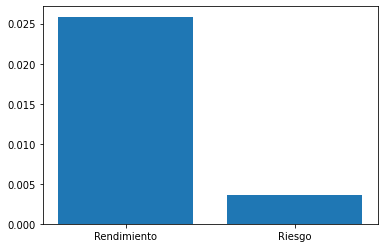

In [ ]:
ren = ganancia(poblacion[0])
ri = riesgo(poblacion[0],covar)
plt.bar(['Rendimiento','Riesgo'], [ren,ri])

In [ ]:
def funcionObjetivo(poblacionIN):
    numerador = ganancia(poblacionIN)
    denominador = riesgo(poblacionIN, covar)
    return numerador/denominador

In [ ]:
def FitnesCalc(poblacionIN):
    ResPT = funcionObjetivo(poblacionIN)
    return ResPT

In [ ]:
def normalizarpob(poblacionIN):
    sumatoria = sum(poblacionIN)
    for i in range(len(poblacionIN)):
        poblacionIN[i] = poblacionIN[i] / sumatoria
    return poblacionIN

In [ ]:
def torneo():
    pdr1, pdr2, pdr3 = random.randint(0,99), random.randint(0,99), random.randint(0,99)
    if (pdr1 == pdr2) and (pdr1 == pdr3):
        pdr2 = random.randint(0,99)
        pdr3 = random.randint(0,99)
    elif (pdr2 == pdr1) and (pdr2 == pdr3):
        pdr1 = random.randint(0,99)
        pdr3 = random.randint(0,99)
    elif (pdr3 == pdr1) and (pdr3 == pdr2):
        pdr1 = random.randint(0,99)
        pdr2 = random.randint(0,99)
    orden = sorted([pdr1, pdr2, pdr3])
    return orden[0],orden[1]

In [ ]:
def seleccion():
    global poblacion
    hijos = []
    evaluar = [FitnesCalc(i) for i in poblacion]
    evaluados =  sorted(zip(evaluar, poblacion), key = lambda x: x[0], reverse = True)
    poblacion = [j[1] for j in evaluados]
    for i in range(40):
        padres = torneo()
        seleccionH = [poblacion[i] for i in padres]
        hijo1,hijo2 = [],[]
        alpha = random.random()
        for j in range(10):
            gen1 = seleccionH[0][j]*(1-alpha)+seleccionH[1][j]*alpha
            gen2 = seleccionH[1][j]*(1-alpha)+seleccionH[0][j]*alpha
            hijo1.append(gen1)
            hijo2.append(gen2)
        hijos.append(normalizarpob(hijo1))
        hijos.append(normalizarpob(hijo2))
    return hijos

In [ ]:
def mutar(hijos):
    mutacion = 0.5
    newDato = 0
    for i in range(0, 78):
        if random.random() <= mutacion:
            cromosomaS = random.randint(0, 78)
            punto = random.randint(0,9)
            newDato = random.random()
            hijos[cromosomaS][punto] = newDato
            hijos[cromosomaS] = normalizarpob(hijos[cromosomaS])
    return hijos

In [ ]:
def reemplazo(hijos):
    global poblacion
    poblacion[40:]=hijos[:]

In [ ]:
def ordenar():
    global poblacion
    orden = [(FitnesCalc(i), i) for i in poblacion]
    pob =  [i[1] for i in sorted(orden, key=lambda orden: orden[0], reverse = True)]
    return pob

In [ ]:
poblacion = generarPoblacion(100)
pob = pd.DataFrame(poblacion)
pob

,0,1,2,3,4,5,6,7,8,9
0,0.152361,0.178948,0.202666,0.025257,0.016562,0.154444,0.029806,0.096314,0.095551,0.048091
1,0.048582,0.067527,0.159375,0.161087,0.202192,0.054654,0.115307,0.091186,0.022753,0.077338
2,0.133058,0.149767,0.061882,0.058188,0.095850,0.134228,0.023227,0.141157,0.137091,0.065552
3,0.011780,0.022982,0.167011,0.167055,0.030910,0.075707,0.088853,0.168275,0.097632,0.169794
4,0.028046,0.142717,0.050460,0.129960,0.057613,0.076002,0.097223,0.107755,0.133322,0.176903
...,...,...,...,...,...,...,...,...,...,...
95,0.174882,0.095909,0.142263,0.020857,0.190702,0.157731,0.047051,0.094698,0.074498,0.001411
96,0.083859,0.100251,0.035435,0.010830,0.134374,0.158554,0.083836,0.150200,0.145559,0.097102
97,0.139812,0.066476,0.107738,0.091716,0.094702,0.096539,0.050278,0.149811,0.117177,0.085750
98,0.007323,0.025710,0.094206,0.124637,0.152791,0.195721,0.156709,0.131592,0.031880,0.079431


In [ ]:
poblacionGr = []
for i in range(500):
    hijos = seleccion()
    hijos = mutar(hijos)
    reemplazo(hijos)
    ordenar()
    poblacionGr.append(funcionObjetivo(poblacion[0]))

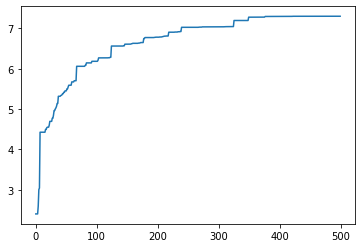

In [ ]:
plt.plot([i for i in range(len(poblacionGr))], poblacionGr)
plt.show()